# Assignement 2

### <span style="color:chocolate"> Submission requirements </span>

Your homework will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:

    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).
---

### Import libraries

In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

### Define functions

In [32]:
def create_1d_data(num_examples, w, b, bound):
  """Create X, Y data with a linear relationship with added noise.

  Args:
    num_examples: number of examples to generate
    w: desired slope
    b: desired intercept
    bound: lower and upper boundary of the data interval

  Returns:
    X and Y with shape (num_examples)
  """
  np.random.seed(4)  # consistent random number generation
  X = np.arange(num_examples)
  deltas = np.random.uniform(low=-bound, high=bound, size=X.shape) # added noise
  Y = b + deltas + w * X

  return X, Y

---
### Step 1: Data ingestion

Let's start by creating some artificial data using the <span style="color:chocolate">create_1d_data()</span> function defined at the top of the notebook.

In [33]:
# Define parameters
num_examples = 70
w = 2
b = 1
bound = 1

# Create data
X, Y = create_1d_data(num_examples, w, b, bound)

# Print shapes
print('Printing shape of X:', X.shape)
print('Printing first 10 elements in X:', X[:10])
print('\nPrinting shape of Y:', Y.shape)
print('Printing first 10 elements in Y:', Y[:10])

Printing shape of X: (70,)
Printing first 10 elements in X: [0 1 2 3 4 5 6 7 8 9]

Printing shape of Y: (70,)
Printing first 10 elements in Y: [ 1.93405968  3.0944645   5.94536872  7.42963199  9.39545765 10.43217899
 13.95254891 14.01246051 16.50596472 18.86958306]


---
### Step 2: Data Preprocessing

Our objectives here involve adding one more feature to X and creating data partitions.

### <span style="color:chocolate">Exercise 1:</span> Adding features (10 points)

1. Add a column of $1s$ to $X$ (this will serve as an intercept or "bias" in our modeling task later on). Note: do not create a new array, just concatenate with the current values;
2. Print the shape of the array.

In [34]:
# YOUR CODE HERE
# Concatenate a column of 1 to X
X = np.c_[X, np.ones(X.shape[0])]

# Print the shape of X
print('Printing shape of X:', X.shape)

Printing shape of X: (70, 2)


### <span style="color:chocolate">Exercise 2:</span> Data splits (10 points)

Using the <span style="color:chocolate">train_test_split()</span> method available in scikit-learn:
1. Split the (X,Y) data into training and test paritions by setting test_size=0.2 and random_state=1234. All the other arguments of the method are set to default values. Name the resulting arrays X_train, X_test, Y_train, Y_test;
2. Print the shape of each array.

In [35]:
# YOUR CODE HERE
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1234)

# Print the shapes of the training and testing sets
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape)

Shape of X_train: (56, 2)
Shape of Y_train: (56,)
Shape of X_test: (14, 2)
Shape of Y_test: (14,)


---
### Step 3: Exploratory data analysis (EDA)

### <span style="color:chocolate">Exercise 3:</span> Plots (10 points)

Create a side-by-side histogram for the values in Y_train and X_train. Make sure to include axes name and titles for each subplot.

Text(0, 0.5, 'Frequency')

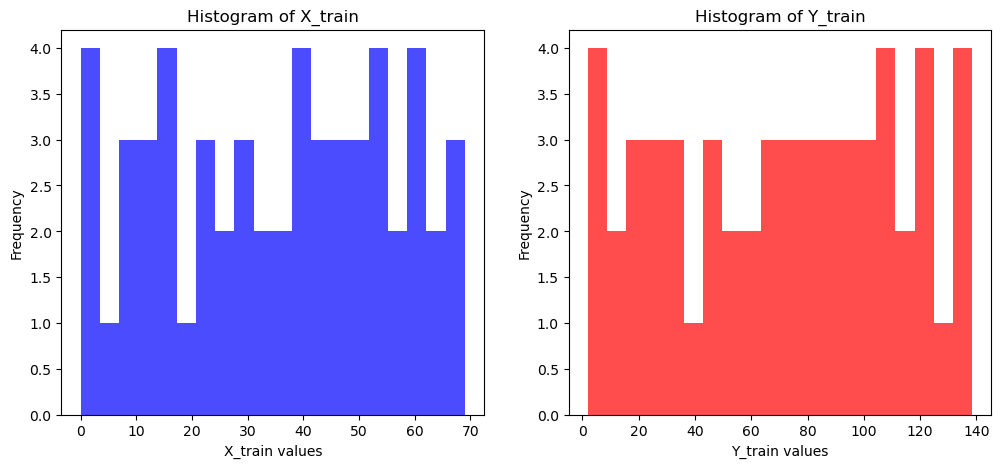

In [36]:
# YOUR CODE HERE
# Create histograms for X_train and Y_train
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(X_train[:, 0], bins=20, color='blue', alpha=0.7)
plt.title('Histogram of X_train')
plt.xlabel('X_train values')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(Y_train, bins=20, color='red', alpha=0.7)
plt.title('Histogram of Y_train')
plt.xlabel('Y_train values')
plt.ylabel('Frequency')


---
### Step 4: Modeling

Let's start by considering the two models proposed in Assignment 1:
1. $M_1(x) = 5+x$ 
2. $M_2(x) = 1+2x$

### <span style="color:chocolate">Exercise 4:</span> Practice with Parameters (10 points)

Perform the following computations:

1. Use matrix multiplication (np.dot) to create $M_1$ and $M_2$ (as previously defined) to produce vectors of predictions using the X_train data. Call these predictions M1_hat_train, M2_hat_train. Hint: the "learned" parameters are alredy provided to you;
3. Print the shapes of the predictions to verify that they match the shape of Y_train.

In [37]:
# YOUR CODE HERE
# Create M1 and M2 model parameters
M1 = np.array([w, b])  # Model parameters for M1
M2 = np.array([w + 0.5, b - 0.5])  # Model parameters for M2

# Create predictions for M1 and M2 using X_train
M1_hat_train = np.dot(X_train, M1)
M2_hat_train = np.dot(X_train, M2)

# Print the shape of the predictions
print('Shape of M1_hat_train:', M1_hat_train.shape)
print('Shape of M2_hat_train:', M2_hat_train.shape)

Shape of M1_hat_train: (56,)
Shape of M2_hat_train: (56,)


### <span style="color:chocolate">Exercise 5:</span> Learn parameters with Gradient Descent (20 points)

1. Fill in the <span style="color:green">NotImplemented</span> parts of the <span style="color:chocolate">gradient_descent()</span> function below. Hint: refer to ``02 Linear Regression_helper.ipynb file``;

2. Run this function with our artificial (X_train, Y_train) data . Set learning_rate = .0002 and num_epochs = 5. Print out the weights and loss after each epoch. 

3. Generate a plot with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title.

In [38]:
num_epochs = 5
for i in range(num_epochs):
    print(i)

0
1
2
3
4


In [41]:
def gradient_descent(inputs, outputs, learning_rate, num_epochs):
  """Apply the gradient descent algorithm to learn learn linear regression.

  Args:
    inputs: A 2-D array where each column is an input feature and each
            row is a training example.
    outputs: A 1-D array containing the real-valued
             label corresponding to the input data in the same row.
    learning_rate: The learning rate to use for updates.
    num_epochs: The number of passes through the full training data.

  Returns:
    weights: A 2-D array with the learned weights after each training epoch.
    losses: A 1-D array with the loss after each epoch.
  """
  # m = number of examples, n = number of features
  m, n = inputs.shape
  
  # We'll use a vector of size n to store the learned weights and initialize
  # all weights to 1. 
  W = np.ones(n)
  
  # Keep track of the training loss and weights after each step.
  losses = []
  weights = []
  
  for epoch in range(num_epochs):
    # Append the old weights to the weights list to keep track of them.
    weights.append(W)

    # Evaluate the current predictions for the training examples given
    # the current estimate of W. 
    predictions = np.dot(inputs, W)
    
    # Find the difference between the predictions and the actual target
    # values.
    diff = predictions - outputs
    
    # In standard linear regression, we want to minimize the sum of squared
    # differences. Compute the mean squared error loss. Don't bother with the
    # 1/2 scaling factor here.
    loss = np.mean(diff ** 2)

    # Append the loss to the losses list to keep a track of it.
    losses.append(loss)
    
    # Compute the gradient with respect to the loss.
    # [Formula (4) in the Gradient Descent Implementation]
    gradient = (2 / m) * np.dot(inputs.T, diff)

    # Update weights, scaling the gradient by the learning rate.
    W = W - learning_rate * gradient

  # Append the final weights after the loop
  weights.append(W)
      
  return np.array(weights), np.array(losses)

Text(0, 0.5, 'Loss')

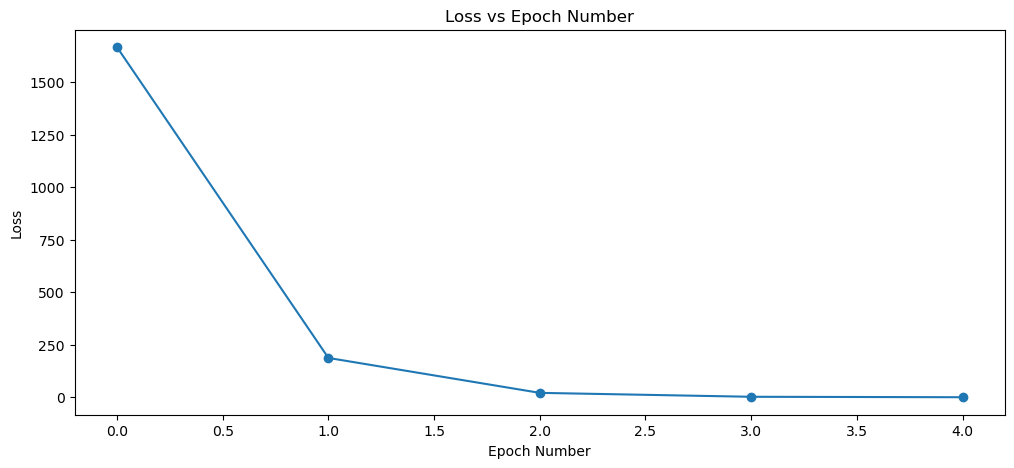

In [50]:
# YOUR CODE HERE
# Run gradient descent on the training data
learning_rate = 0.0002
num_epochs = 5
weights, losses = gradient_descent(X_train, Y_train, learning_rate, num_epochs)

# Generate a plot with the loss values and the epoch number
plt.figure(figsize=(12, 5))
plt.plot(range(num_epochs), losses, marker='o')
plt.title('Loss vs Epoch Number')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')


---
### Step 5: Hyperparameter tuning

Hyperparameter tuning plays an important role in optimizing ML models. One systematically adjusts hyperparameters to find the right balance between model complexity and generalization, ultimately leading to better predictive performance and model effectiveness.

Note that hyperparameter tuning is typically performed on **a separate validation dataset**. However, for the purposes of this assignment and based on the ML knowledge you've acquired thus far, we will perform hyperparameter tuning directly on the training data.

### <span style="color:chocolate">Exercise 6:</span> Tuning hyperparameters (10 points)

Answer the following questions:
    
1. Do you think it would be beneficial to extend the model training in Exercise 5 by increasing the learning rate to 0.02? Justify your answer;

2. Restoring to the previous learning_rate = .0002, would you  consider extending the model training in Exercise 5 by increasing the number of epochs to 10? Justify your answer.

Note: to support your answers, we recommend the following actions:
- create side-by-side subplots to show the loss at each epoch (make sure to include axes name and title), and
- print the loss at the last epoch under the following scenarios:
    - learning_rate=.0002, num_epochs=5;
    - learning_rate=.02, num_epochs=5;
    - learning_rate=.0002, num_epochs=10.

Text(0, 0.5, 'Loss')

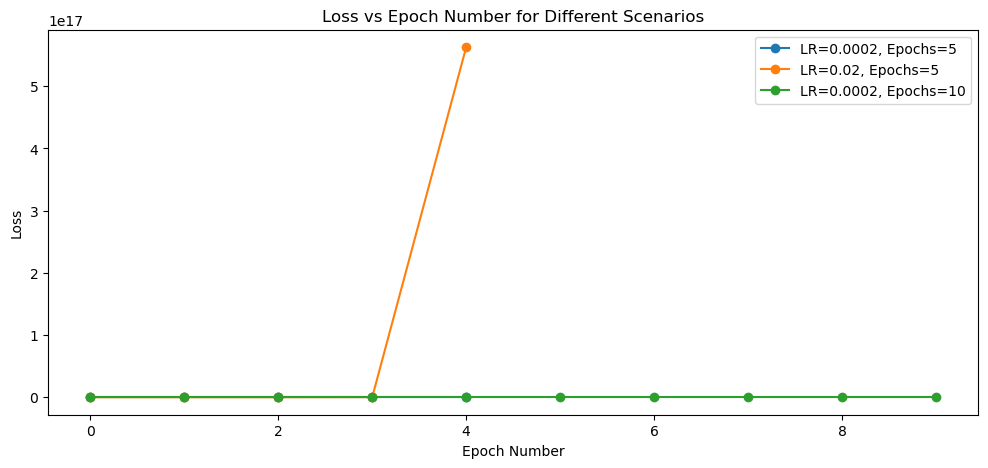

In [ ]:
# YOUR CODE HERE
# Scenario 1: learning rate=.0002, epochs=5
weights_1, losses_1 = gradient_descent(X_train, Y_train, 0.0002, 5)

# Scenario 2: learning rate=.02, epochs=5
weights_2, losses_2 = gradient_descent(X_train, Y_train, 0.02, 5)

# Scenario 3: learning rate=.0002, epochs=10
weights_3, losses_3 = gradient_descent(X_train, Y_train, 0.0002, 10)

# Generate a plot with the loss values and the epoch number for all three scenarios
plt.figure(figsize=(12, 5))
plt.plot(range(5), losses_1, marker='o', label='LR=0.0002, Epochs=5')
plt.plot(range(5), losses_2, marker='o', label='LR=0.02, Epochs=5')
plt.plot(range(10), losses_3, marker='o', label='LR=0.0002, Epochs=10')
plt.title('Loss vs Epoch Number for Different Scenarios')
plt.xlabel('Epoch Number')
plt.legend()
plt.ylabel('Loss')

# 1. I do not think it is beneficial to have a learning rate that is too high, as it can cause the loss to diverge and not converge to a minimum.
#    In scenario 2 with a learning rate of 0.02, the loss values are much higher and do not decrease over epochs compared to scenario 1, indicating that the model is not learning effectively.

# 2. Increasing the number of epochs may help the model converge to a better solution. However, scenario 3 with 10 epochs does not show a significant improvement in loss compared to scenario 1 with 5 epochs.
#    This suggests that simply increasing the number of epochs may not always lead to better performance if the learning rate is not appropriately set.


### <span style="color:chocolate">Exercise 7:</span> Choosing the best model (10 points)

Write down the learned model that you consider most optimal given your answers to the hyperparameter tuning exercise. Call this model $M_3(x)$.

In [55]:
# YOUR ANSWER HERE
# The most optimal learned model is scenario 1 with the lowest loss values and a learning rate that allows for convergence.
M3 = weights_1[-1]

---
### Step 6: Evaluation and Generalization

To evaluate our models, we assess their performance based on how closely they fit the available data. In other words, we compare the true value $y$ with the predicted value $\hat{y}$ for each $x$.

### <span style="color:chocolate">Exercise 8:</span> Computing MSE (10 points)

Assess the performance of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) by computing the MSE metric on the training dataset. Hint: you can use the <span style="color:chocolate">mean_squared_error()</span> method available in sklearn.metrics.

In [56]:
# YOUR CODE HERE
# Assess the performance of M1, M2, and M3 on the test set using mean squared error
M1_predictions = np.dot(X_test, M1)
M2_predictions = np.dot(X_test, M2)
M3_predictions = np.dot(X_test, M3)
M1_mse = mean_squared_error(Y_test, M1_predictions)
M2_mse = mean_squared_error(Y_test, M2_predictions)
M3_mse = mean_squared_error(Y_test, M3_predictions)
print('M1 Mean Squared Error:', M1_mse)
print('M2 Mean Squared Error:', M2_mse)
print('M3 Mean Squared Error:', M3_mse)

M1 Mean Squared Error: 0.2908006971666422
M2 Mean Squared Error: 323.5056179186522
M3 Mean Squared Error: 0.29457180062784716


### <span style="color:chocolate">Exercise 9:</span> Generalization (10 points)

Which of the three models ($M_1(x)$, $M_2(x)$, $M_3(x)$) demonstrates better generalization ability? Hint: compare training vs. test MSE.

In [ ]:
# YOUR CODE HERE
# Compare the training vs test MSE for M1, M2, and M3
M1_train_mse = mean_squared_error(Y_train, M1_hat_train)
M2_train_mse = mean_squared_error(Y_train, M2_hat_train)
M3_train_predictions = np.dot(X_train, M3)
M3_train_mse = mean_squared_error(Y_train, M3_train_predictions)
print('M1 Train MSE:', M1_train_mse)
print('M2 Train MSE:', M2_train_mse)
print('M3 Train MSE:', M3_train_mse)

# The M1 model has the lowest MSE on both the training and test sets, indicating that it performs better than M2 and M3, demonstrating better generalization ability.


M1 Train MSE: 0.3280557752885262
M2 Train MSE: 396.37667716700224
M3 Train MSE: 0.3542629436554315


----
### <span style="color:chocolate">Exercise 10:</span> Additional practice (not graded)

1. How does stochastic gradient descent (SGD) differ from the gradient descent (GD) approach implemented in Exercise 5?
2. Determine the optimal weights for model $M_3(x)$ using SGD. Does SGD converge more rapidly? Explain the reasons for your answer.

In [ ]:
# YOUR ANSWER HERE
1.  The difference lies in how much data is used to update the weights in each iteration. In GD, the weights are updated after computing the gradient using the entire training dataset, which can be computationally expensive for large datasets.
    In SGD, the weights are updated after computing the gradient using only one training example at a time, which can lead to faster updates and convergence, especially for large datasets. 
    However, SGD can be noisier and may not converge as smoothly as GD.
2.  SGD converges more rapidly than GD because it updates the weights more frequently, allowing it to make progress towards the minimum loss more quickly. GD, on the other hand, may take longer to converge as it waits until the end of each epoch to update the weights.

In [61]:
# YOUR CODE HERE
def stochastic_gradient_descent(inputs, outputs, learning_rate, num_epochs):
    """Apply Stochastic Gradient Descent to learn linear regression.

    Args:
        inputs: A 2-D array where each column is an input feature and each
                row is a training example.
        outputs: A 1-D array containing the real-valued
                 label corresponding to the input data in the same row.
        learning_rate: The learning rate to use for updates.
        num_epochs: The number of passes through the full training data.

    Returns:
        weights: A 2-D array with the learned weights after each training epoch.
        losses: A 1-D array with the MSE loss after each epoch.
    """
    # m = number of examples, n = number of features
    m, n = inputs.shape
    
    # We'll use a vector of size n to store the learned weights and initialize
    # all weights to 1. 
    W = np.ones(n)
    
    # Keep track of the training loss and weights after each step.
    losses = []
    weights = []
    
    for epoch in range(num_epochs):
        # Append the old weights to the weights list to keep track of them.
        weights.append(W)

        # Shuffle the training data at the beginning of each epoch
        indices = np.arange(m)
        np.random.shuffle(indices)
        inputs_shuffled = inputs[indices]
        outputs_shuffled = outputs[indices]

        for i in range(m):
            # Get the current training example and its corresponding output
            x_i = inputs_shuffled[i].reshape(1, -1)  # Reshape for matrix multiplication
            y_i = outputs_shuffled[i]

            # Evaluate the current prediction for the training example given
            # the current estimate of W. 
            prediction = np.dot(x_i, W)

            # Find the difference between the prediction and the actual target value.
            diff = prediction - y_i

            # Compute the mean squared error loss for this example
            loss = diff ** 2

            # Append the loss to the losses list to keep a track of it.
            losses.append(loss)

            # Compute the gradient with respect to the loss for this example
            gradient = 2 * np.dot(x_i.T, diff)

            # Update weights, scaling the gradient by the learning rate.
            W = W - learning_rate * gradient

    # Append the final weights after all epochs
    weights.append(W)
      
    return np.array(weights, dtype=object), np.array(losses)

# Determine optimal weights for M3 using stochastic gradient descent
weights_3_sgd, losses_3_sgd = stochastic_gradient_descent(X_train, Y_train, 0.0002, 5)

# Print the final weights and losses for M3 using SGD
print('Final weights for M3 using SGD:', weights_3_sgd[-1])

Final weights for M3 using SGD: [2.0002840570875033 1.0260691665524826]
